# Set up

In [88]:
import sys
from pathlib import Path

sys.path.append(str(Path().resolve().parents[1]))

In [89]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from abc import ABC, abstractmethod

In [90]:
from utils import *

## Constants

In [91]:
SEED = 42
LEARNING_RATE = 0.01
MAX_ITER = 10000

# Process data

In [92]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# 1. ĐỌC DỮ LIỆU TỪ FILE CSV ĐÃ LƯU
try:
    df = pd.read_csv('data/dataset.csv')
    print("Đã tải dữ liệu thành công.")
except FileNotFoundError:
    print("Lỗi: Không tìm thấy file 'dataset.csv'. Hãy chạy file xử lý trước đó.")
    exit()

# 2. TÁCH BIẾN ĐẶC TRƯNG (X) VÀ BIẾN MỤC TIÊU (y)
# Loại bỏ cột 'Class' (chuỗi) và 'Class_Encoded' (mục tiêu) ra khỏi X
X = df.drop(['Class', 'Class_Encoded'], axis=1)
y = df['Class_Encoded']

# 3. CHIA DỮ LIỆU: TRAIN (70%) / VAL (10%) / TEST (20%)
# Bước 1: Tách 20% cho Test
X_train_val, X_test, y_train_val, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

# Bước 2: Tách 10% (trên tổng số) cho Validation từ phần 80% còn lại
# Tỷ lệ test_size = 0.125 vì 0.125 * 0.8 = 0.1 (tức 10%)
X_train, X_val, y_train, y_val = train_test_split(
    X_train_val, y_train_val, test_size=0.125, random_state=42, stratify=y_train_val
)

# 4. CHUẨN HÓA DỮ LIỆU (STANDARDIZATION)
# Khởi tạo bộ chuẩn hóa
scaler = StandardScaler()

# LƯU Ý: Chỉ "fit" trên tập Train để tránh rò rỉ dữ liệu (Data Leakage)
X_train_scaled = scaler.fit_transform(X_train)

# "transform" cho tập Val và Test dựa trên thông số của tập Train
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

# 5. KIỂM TRA KẾT QUẢ
print("-" * 30)
print(f"Tổng số mẫu: {len(df)}")
print(f"Tập Huấn luyện (Train):    {X_train_scaled.shape}")
print(f"Tập Kiểm chứng (Val):     {X_val_scaled.shape}")
print(f"Tập Kiểm tra (Test):      {X_test_scaled.shape}")
print("-" * 30)

Đã tải dữ liệu thành công.
------------------------------
Tổng số mẫu: 13611
Tập Huấn luyện (Train):    (9527, 9)
Tập Kiểm chứng (Val):     (1361, 9)
Tập Kiểm tra (Test):      (2723, 9)
------------------------------


# Model

# Logistic Regression

hypothesis: $h_{\theta}(x) = g(\theta^T x)$

sigmoid function: $g(z) = \frac{1}{1 + e^{-z}}$

$0 \ge h_{\theta}(x) \le 1$ 

$h_{\theta}(x) = g(\theta^T x) = \frac{1}{1 + e^{-\theta^T x}}$ can be interpreted as the posterior probability. For classification
use step function:  
$h_{\theta}(x) \le 0.5 \rightarrow 0$   
$h_{\theta}(x) > 0.5 \rightarrow 1$ 

$h_{\theta}(x):  \theta_1 x_1 + \dots + \theta_n x_n >  \theta_0$

equivalent to 

$h_{\theta}(x) = -\theta_0 + \theta_1 x_1 + \dots + \theta_n x_n > 0$

Linear Regression Cost function (gradiend descent):
    
$J(\theta) = \frac{1}{2m} \sum (h_{\theta}(x^{(i)}) - y)^2$

Now using  $\frac{1}{1 + e^{-\theta^T x}}$ (not convex anymore)

### Cost Function and Gradient

$J(\theta) = \frac{1}{m} \sum^{m}_{i=1} \big[ -y^{(i)} log(h_{\theta}(x^{(i)})) - (1-y^{(i)})log(1-h_{\theta}(x^{(i)}))  \big]$

$\frac{\partial J(\theta)}{\partial \theta_j} = \frac{1}{m} \sum_{i=1}^{m}(h_\theta(x^{(i)}) - y^{(i)}) x^{(i)}_j$

### Update Rule

$\theta_j := \theta_j - \alpha \sum_{i=1}^{m}(h_\theta(x^{(i)}) - y^{(i)}) x^{(i)}_j$

## Regularization

$$J(\theta) = \frac{1}{m} \sum^{m}_{i=1} \big[ -y^{(i)} \
log(h_{\theta}(x^{(i)})) - \
(1-y^{(i)})log(1-h_{\theta}(x^{(i)}))  \big]\
%regularize\
+ \frac{\lambda}{2m} \sum_{j=1}^{n} \theta^2_j$$

Do not regularize $\theta_0$

$$\frac{\partial J(\theta)}{\partial \theta_0} = \frac{1}{m} \sum_{i=1}^{m}(h_\theta(x^{(i)}) - y^{(i)}) x^{(i)}_j \
\quad \quad \text{for } j = 0$$

$$\frac{\partial J(\theta)}{\partial \theta_j} = \frac{1}{m} \sum_{i=1}^{m}(h_\theta(x^{(i)}) - y^{(i)}) x^{(i)}_j \
+ \frac{\lambda}{m} \theta_j \
\quad \quad \text{for } j \ge 1$$

## Base

In [93]:
class Classification(ABC):
  @abstractmethod
  def fit(self, X: np.ndarray, y: np.ndarray) -> None:
    """
    Fit the model to the training data.
    """
    pass

  @abstractmethod
  def predict(self, X: np.ndarray) -> np.ndarray:
    """
    Predict the target values for the given input data.
    """
    pass

  @abstractmethod
  def evaluate(self, y_hat: np.ndarray, y: np.ndarray) -> float:
    """
    Evaluate the model on the given input and target data.
    """
    pass

## Logistic Regression

In [94]:
class LogisticRegression(Classification):
  def __init__(
    self,
    random_state: int = SEED ,
    solver: str = 'gradient_descent',
    learning_rate: float = LEARNING_RATE,
    max_iter: int = MAX_ITER,
  ):
    self.random_state = random_state
    self.solver = solver
    self.learning_rate = learning_rate
    self.max_iter = max_iter
    self.coef_ = None
    self.intercept_ = None
    
  def fit(self, X: np.ndarray, y: np.ndarray) -> None:
    raise NotImplementedError('Not implemented yet')

  def predict(self, X: np.ndarray) -> np.ndarray:
    raise NotImplementedError('Not implemented yet')

  def evaluate(self, y_hat: np.ndarray, y: np.ndarray) -> float:
    raise NotImplementedError('Not implemented yet')

# Logistic Regression (nhị phân và đa lớp):


Cài đặt Gradient Descent từ đầu cho nhị phân (sigmoid) và đa lớp (softmax).

In [95]:
import numpy as np

def sigmoid(x):
    return 1 / (1 + np.exp(-x))

def softmax(x):
    e_x = np.exp(x - np.max(x)) # Subtracting max(x) for numerical stability
    return e_x / e_x.sum(axis=0)

In [96]:
import numpy as np

class LogisticRegression:
    def __init__(
        self,
        random_state: int = 42,
        solver: str = 'gradient_descent',
        learning_rate: float = 0.01,
        max_iter: int = 1000,
    ):
        self.random_state = random_state
        self.solver = solver
        self.learning_rate = learning_rate
        self.max_iter = max_iter
        self.coef_ = None
        self.intercept_ = None

    def _sigmoid(self, z: np.ndarray) -> np.ndarray:
        """
        Maps values to [0, 1] với cơ chế clipping để tránh lỗi overflow.
        """
        # Giới hạn giá trị z trong khoảng [-250, 250] để tránh exp(z) quá lớn
        z = np.clip(z, -250, 250)
        return 1 / (1 + np.exp(-z))

    def fit(self, X: np.ndarray, y: np.ndarray) -> None:
        if self.random_state:
            np.random.seed(self.random_state)
            
        n_samples, n_features = X.shape
        
        # Khởi tạo trọng số và bias
        self.coef_ = np.zeros(n_features)
        self.intercept_ = 0

        # Vòng lặp Gradient Descent
        for _ in range(self.max_iter):
            # 1. Tính toán z = Xw + b
            model_linear = np.dot(X, self.coef_) + self.intercept_
            
            # 2. Dự đoán xác suất p
            y_predicted = self._sigmoid(model_linear)

            # 3. Tính toán đạo hàm (Gradients)
            dw = (1 / n_samples) * np.dot(X.T, (y_predicted - y))
            db = (1 / n_samples) * np.sum(y_predicted - y)

            # 4. Cập nhật tham số
            self.coef_ -= self.learning_rate * dw
            self.intercept_ -= self.learning_rate * db

    def predict_proba(self, X: np.ndarray) -> np.ndarray:
        """Trả về xác suất của lớp dương (lớp 1)."""
        model_linear = np.dot(X, self.coef_) + self.intercept_
        return self._sigmoid(model_linear)

    def predict(self, X: np.ndarray) -> np.ndarray:
        """Dự đoán nhãn lớp (0 hoặc 1)."""
        # Sử dụng ngưỡng 0.5 trên xác suất
        y_probs = self.predict_proba(X)
        return np.where(y_probs > 0.5, 1, 0)

    def evaluate(self, y_hat: np.ndarray, y: np.ndarray) -> float:
        """Tính toán độ chính xác (Accuracy)."""
        return np.mean(y_hat == y)

In [97]:
import numpy as np
from itertools import combinations

class MulticlassLogisticRegression(LogisticRegression):
    def __init__(self, method='ovr', **kwargs):
        # Khởi tạo class cha để lưu các tham số cấu hình (lr, max_iter, SEED...)
        super().__init__(**kwargs)
        self.method = method
        self.models = []
        self.classes_ = None

    def fit(self, X: np.ndarray, y: np.ndarray) -> None:
        self.classes_ = np.unique(y)
        self.models = []

        if self.method == 'ovr':
            for c in self.classes_:
                # 1 vs All: Lớp hiện tại là 1, tất cả các lớp khác là 0
                y_binary = np.where(y == c, 1, 0)
                model = LogisticRegression(
                    random_state=self.random_state,
                    learning_rate=self.learning_rate,
                    max_iter=self.max_iter
                )
                model.fit(X, y_binary)
                self.models.append(model)

        elif self.method == 'ovo':
            # 1 vs 1: Huấn luyện bộ phân lớp cho từng cặp (c1, c2)
            for c1, c2 in combinations(self.classes_, 2):
                mask = (y == c1) | (y == c2)
                X_pair = X[mask]
                # Chuyển nhãn về 1 (c1) và 0 (c2) để mô hình nhị phân hiểu được
                y_pair = np.where(y[mask] == c1, 1, 0)
                
                model = LogisticRegression(
                    random_state=self.random_state,
                    learning_rate=self.learning_rate,
                    max_iter=self.max_iter
                )
                model.fit(X_pair, y_pair)
                self.models.append(((c1, c2), model))

    def predict(self, X: np.ndarray) -> np.ndarray:
        if not self.models:
            raise ValueError("Mô hình chưa được huấn luyện (fit).")

        if self.method == 'ovr':
            # Thu thập xác suất từ mỗi mô hình con
            # Mỗi model.predict_proba trả về mảng xác suất lớp dương (1)
            all_probs = []
            for model in self.models:
                all_probs.append(model.predict_proba(X))
            
            all_probs = np.array(all_probs).T # Shape: (n_samples, n_classes)
            
            # Chọn lớp có xác suất (confidence score) cao nhất
            best_class_indices = np.argmax(all_probs, axis=1)
            return self.classes_[best_class_indices]

        elif self.method == 'ovo':
            # Thu thập dự đoán (phiếu bầu) từ từng cặp đấu
            all_votes = []
            for (c1, c2), model in self.models:
                preds = model.predict(X)
                # Nếu preds == 1 chọn c1, ngược lại chọn c2
                votes = np.where(preds == 1, c1, c2)
                all_votes.append(votes)
            
            all_votes = np.array(all_votes).T # Shape: (n_samples, n_combinations)
            
            # Đếm số phiếu bầu (Majority Voting) cho mỗi dòng
            final_preds = []
            for row in all_votes:
                # Tìm class xuất hiện nhiều nhất trong các cặp đấu
                counts = np.bincount(row.astype(int))
                final_preds.append(np.argmax(counts))
                
            return np.array(final_preds)

    def predict_proba(self, X: np.ndarray) -> np.ndarray:
        """Trả về ma trận xác suất (n_samples, n_classes) cho OvR."""
        if self.method == 'ovr':
            all_probs = []
            for model in self.models:
                all_probs.append(model.predict_proba(X))
            
            all_probs = np.array(all_probs).T
            # Chuẩn hóa để tổng xác suất các lớp bằng 1 (giống Softmax)
            return all_probs / all_probs.sum(axis=1, keepdims=True)
        else:
            raise NotImplementedError("predict_proba hiện chưa hỗ trợ tối ưu cho OvO.")

In [98]:
import numpy as np

class SoftmaxRegression(LogisticRegression):
    def __init__(self, **kwargs):
        super().__init__(**kwargs)
        self.n_classes = None

    def _softmax(self, z: np.ndarray) -> np.ndarray:
        """
        Tính Softmax một cách ổn định (tránh tràn số bằng cách trừ đi max).
        z có shape: (n_samples, n_classes)
        """
        exp_z = np.exp(z - np.max(z, axis=1, keepdims=True))
        return exp_z / np.sum(exp_z, axis=1, keepdims=True)

    def fit(self, X: np.ndarray, y: np.ndarray) -> None:
        if self.random_state:
            np.random.seed(self.random_state)
            
        n_samples, n_features = X.shape
        self.classes_ = np.unique(y)
        self.n_classes = len(self.classes_)
        
        # 1. One-hot encoding cho y: (n_samples, n_classes)
        y_encoded = np.zeros((n_samples, self.n_classes))
        for i, cls in enumerate(self.classes_):
            y_encoded[y == cls, i] = 1

        # 2. Khởi tạo trọng số: (n_features, n_classes)
        self.coef_ = np.zeros((n_features, self.n_classes))
        self.intercept_ = np.zeros(self.n_classes)

        # Gradient Descent Loop
        for _ in range(self.max_iter):
            # Tính Linear: (n_samples, n_classes)
            z = np.dot(X, self.coef_) + self.intercept_
            
            # Tính Softmax: (n_samples, n_classes)
            y_predicted = self._softmax(z)

            # 3. Tính Gradients (Đạo hàm của Cross-Entropy với Softmax)
            # Tương tự sigmoid, gradient = (1/n) * X.T * (y_pred - y_true)
            dw = (1 / n_samples) * np.dot(X.T, (y_predicted - y_encoded))
            db = (1 / n_samples) * np.sum(y_predicted - y_encoded, axis=0)

            # 4. Cập nhật tham số
            self.coef_ -= self.learning_rate * dw
            self.intercept_ -= self.learning_rate * db

    def predict(self, X: np.ndarray) -> np.ndarray:
        """Dự đoán lớp có xác suất cao nhất."""
        z = np.dot(X, self.coef_) + self.intercept_
        y_predicted = self._softmax(z)
        # Lấy index của xác suất lớn nhất
        class_indices = np.argmax(y_predicted, axis=1)
        return self.classes_[class_indices]

    def predict_proba(self, X: np.ndarray) -> np.ndarray:
        """Trả về xác suất của từng lớp."""
        z = np.dot(X, self.coef_) + self.intercept_
        return self._softmax(z)

Cài đặt Newton–Raphson / IRLS cho bài toán nhị phân và so sánh tốc độ
hội tụ (loss vs. epoch, loss vs. wall-clock time)

In [99]:
import numpy as np
import time

class NewtonLogisticRegression(LogisticRegression):
    def fit(self, X: np.ndarray, y: np.ndarray) -> None:
        n_samples, n_features = X.shape
        
        # Thêm cột bias (1) vào đầu ma trận X: [1, x1, x2, ...]
        X_bias = np.c_[np.ones(n_samples), X]
        
        # Khởi tạo theta (bao gồm cả intercept ở vị trí index 0)
        self.theta = np.zeros(n_features + 1)
        
        self.loss_history = []
        self.time_history = []
        start_time = time.time()

        for i in range(self.max_iter):
            # 1. Dự đoán xác suất: p = sigmoid(X_bias * theta)
            z = np.dot(X_bias, self.theta)
            p = self._sigmoid(z)
            
            # 2. Tính Loss (Log-Loss) có thêm epsilon để tránh log(0)
            epsilon = 1e-15
            loss = -np.mean(y * np.log(p + epsilon) + (1 - y) * np.log(1 - p + epsilon))
            self.loss_history.append(loss)
            self.time_history.append(time.time() - start_time)

            # 3. Tính Gradient (g): g = (1/n) * X^T * (p - y)
            gradient = np.dot(X_bias.T, (p - y)) / n_samples
            
            # 4. Tính Hessian (H): H = (1/n) * X^T * W * X
            # W là ma trận đường chéo với W_ii = p_i * (1 - p_i)
            # Tối ưu: Thay vì tạo ma trận diag khổng lồ, ta nhân trực tiếp vector
            W_ii = (p * (1 - p)).reshape(-1, 1)
            hessian = np.dot(X_bias.T, W_ii * X_bias) / n_samples
            
            # 5. Cập nhật Newton: theta = theta - H^-1 * g
            try:
                # Thêm Ridge regularization nhỏ (1e-6) để đảm bảo Hessian luôn khả nghịch
                reg_matrix = 1e-6 * np.eye(n_features + 1)
                self.theta -= np.linalg.solve(hessian + reg_matrix, gradient)
            except np.linalg.LinAlgError:
                print("Hessian matrix is singular, stopping at iteration", i)
                break

            # Kiểm tra hội tụ (dựa trên sự thay đổi của loss)
            if i > 0 and abs(self.loss_history[-1] - self.loss_history[-2]) < 1e-8:
                break
        
        # Cập nhật lại thuộc tính của lớp cha để hàm predict/predict_proba hoạt động
        self.intercept_ = self.theta[0]
        self.coef_ = self.theta[1:]

Cho bài toán đa lớp: so sánh ba chiến lược one-vs-rest, one-vs-one, và
softmax trực tiếp.

### Bảng so sánh các chiến lược phân lớp đa lớp

| Tiêu chí | One-vs-Rest (OvR) | One-vs-One (OvO) | Softmax Regression (Multinomial) |
| :--- | :--- | :--- | :--- |
| **Cơ chế hoạt động** | Huấn luyện $K$ bộ phân lớp nhị phân. Mỗi bộ phân biệt 1 lớp với tất cả các lớp còn lại. | Huấn luyện $K(K-1)/2$ bộ phân lớp. Mỗi bộ phân biệt giữa một cặp lớp $(i, j)$. | Huấn luyện **một** mô hình duy nhất với hàm kích hoạt Softmax để tính xác suất cho tất cả các lớp. |
| **Số lượng mô hình** | $K$ (Ví dụ: 3 lớp $\rightarrow$ 3 mô hình) | $K(K-1)/2$ (Ví dụ: 3 lớp $\rightarrow$ 3 mô hình; 10 lớp $\rightarrow$ 45 mô hình) | **1** (Mô hình hợp nhất) |
| **Độ phức tạp huấn luyện** | Thấp. Mỗi mô hình chạy trên toàn bộ tập dữ liệu. | Cao về số lượng mô hình, nhưng mỗi mô hình chỉ chạy trên dữ liệu của 2 lớp (nhanh hơn). | Trung bình. Cần tính toán ma trận trọng số lớn hơn và dùng hàm mất mát Cross-Entropy. |
| **Cách dự đoán** | Chọn lớp có xác suất (confidence score) cao nhất từ $K$ mô hình. | Bỏ phiếu (Voting). Lớp nào thắng nhiều cặp đấu nhất sẽ được chọn. | Chọn lớp có giá trị xác suất đầu ra lớn nhất (tổng các xác suất bằng 1). |
| **Ưu điểm** | Dễ cài đặt, trực quan, tốn ít tài nguyên bộ nhớ hơn OvO khi số lớp lớn. | Tránh được vấn đề mất cân bằng dữ liệu; hoạt động tốt với SVM hoặc các thuật toán nhạy cảm với kích thước dữ liệu. | Chính xác nhất về mặt toán học vì tối ưu hóa tất cả các lớp cùng lúc; không bị trùng lặp ranh giới. |
| **Nhược điểm** | Dễ bị mất cân bằng dữ liệu (lớp "Rest" thường chiếm đa số); các vùng ranh giới có thể bị chồng lấn. | Số lượng mô hình tăng rất nhanh khi số lớp tăng (bùng nổ tổ hợp). | Yêu cầu thay đổi cấu trúc hàm Loss và đạo hàm (phức tạp hơn khi tự code từ đầu). |

---

Đang huấn luyện Softmax Regression...


Đang huấn luyện One-vs-Rest (OvR)...
Đang huấn luyện One-vs-One (OvO)...

            BẢNG SO SÁNH KẾT QUẢ             
        Chiến lược  Độ chính xác (Accuracy)
Softmax Regression                 0.903783
       One-vs-Rest                 0.868895
        One-vs-One                 0.915167


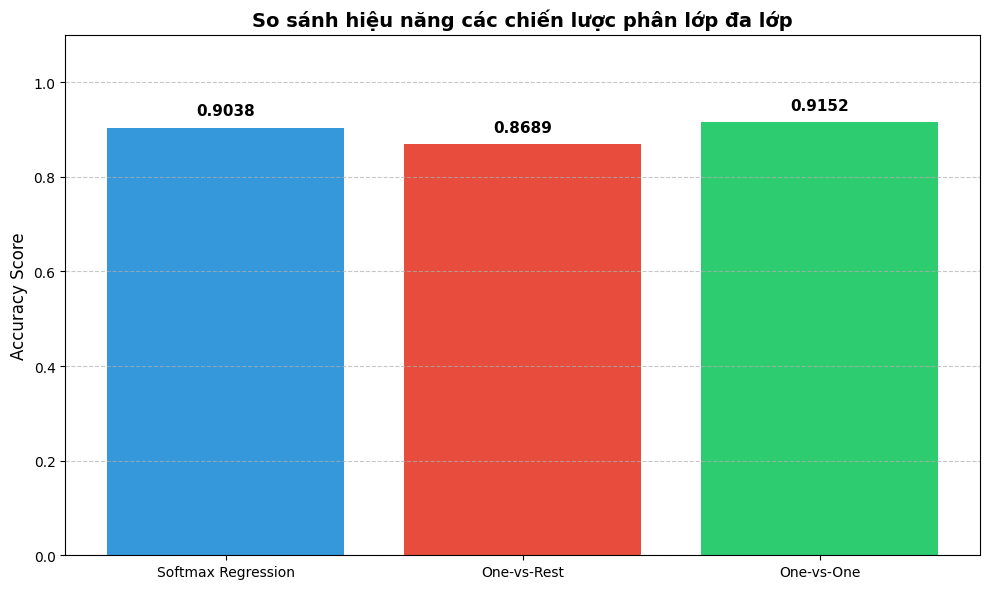

In [100]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# 1. Khởi tạo tham số (Đảm bảo các biến SEED, LEARNING_RATE... đã được định nghĩa)
# Nếu chưa định nghĩa ở trên, bạn có thể bỏ comment dòng dưới:
# SEED, LEARNING_RATE, MAX_ITER = 42, 0.01, 1000

params = {
    'learning_rate': LEARNING_RATE,
    'max_iter': MAX_ITER,
    'random_state': SEED
}

# Danh sách lưu kết quả
results = []

# --- Chiến lược 1: Softmax Regression ---
print("Đang huấn luyện Softmax Regression...")
model_softmax = SoftmaxRegression(**params)
model_softmax.fit(X_train_scaled, y_train)
y_pred_softmax = model_softmax.predict(X_test_scaled)
acc_softmax = model_softmax.evaluate(y_pred_softmax, y_test)
results.append(['Softmax Regression', acc_softmax])

# --- Chiến lược 2: One-vs-Rest (OvR) ---
print("Đang huấn luyện One-vs-Rest (OvR)...")
model_ovr = MulticlassLogisticRegression(method='ovr', **params)
model_ovr.fit(X_train_scaled, y_train)
y_pred_ovr = model_ovr.predict(X_test_scaled)
acc_ovr = model_ovr.evaluate(y_pred_ovr, y_test)
results.append(['One-vs-Rest', acc_ovr])

# --- Chiến lược 3: One-vs-One (OvO) ---
print("Đang huấn luyện One-vs-One (OvO)...")
model_ovo = MulticlassLogisticRegression(method='ovo', **params)
model_ovo.fit(X_train_scaled, y_train)
y_pred_ovo = model_ovo.predict(X_test_scaled)
acc_ovo = model_ovo.evaluate(y_pred_ovo, y_test)
results.append(['One-vs-One', acc_ovo])

# 2. Tổng hợp kết quả vào DataFrame
df_comparison = pd.DataFrame(results, columns=['Chiến lược', 'Độ chính xác (Accuracy)'])

print("\n" + "="*45)
print(f"{'BẢNG SO SÁNH KẾT QUẢ':^45}")
print("="*45)
print(df_comparison.to_string(index=False))
print("="*45)

# 3. Vẽ biểu đồ so sánh trực quan
plt.figure(figsize=(10, 6))
colors = ['#3498db', '#e74c3c', '#2ecc71'] # Màu sắc hiện đại hơn
bars = plt.bar(df_comparison['Chiến lược'], df_comparison['Độ chính xác (Accuracy)'], color=colors)

# Tinh chỉnh biểu đồ
plt.ylim(0, 1.1) # Để dư khoảng trống phía trên cho text
plt.ylabel('Accuracy Score', fontsize=12)
plt.title('So sánh hiệu năng các chiến lược phân lớp đa lớp', fontsize=14, fontweight='bold')
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Thêm số liệu cụ thể lên đầu cột
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height + 0.02,
             f'{height:.4f}', ha='center', va='bottom', fontweight='bold', fontsize=11)

plt.tight_layout()
plt.show()

Trình bày đầy đủ đạo hàm Hessian, Jacobian của softmax.

Để triển khai **Softmax Regression** (còn gọi là Multinomial Logistic Regression) một cách chuyên sâu, việc hiểu các thành phần vi phân như Jacobian và Hessian là cực kỳ quan trọng để tối ưu hóa bằng các thuật toán bậc 1 (Gradient Descent) hoặc bậc 2 (Newton's Method).

Giả sử ta có vector đầu vào $z = [z_1, z_2, ..., z_K]^T$, hàm Softmax $\sigma(z)$ trả về một vector $a$ cùng chiều, với phần tử thứ $i$ là:
$$a_i = \frac{e^{z_i}}{\sum_{j=1}^{K} e^{z_j}}$$

---

### 1. Ma trận Jacobian của Softmax
Ma trận Jacobian $J$ chứa tất cả các đạo hàm riêng bậc nhất của các đầu ra đối với các đầu vào. Vì mỗi $a_i$ phụ thuộc vào tất cả các $z_j$, ma trận này có kích thước $K \times K$.

Phần tử tại hàng $i$, cột $j$ của ma trận Jacobian là $\frac{\partial a_i}{\partial z_j}$:

*   **Trường hợp $i = j$ (Đạo hàm riêng với chính nó):**
    $$\frac{\partial a_i}{\partial z_i} = a_i(1 - a_i)$$
*   **Trường hợp $i \neq j$ (Đạo hàm riêng chéo):**
    $$\frac{\partial a_i}{\partial z_j} = -a_i a_j$$

**Dạng ma trận tổng quát:**
$$J = \text{diag}(a) - aa^T$$
Trong đó $\text{diag}(a)$ là ma trận đường chéo với các phần tử của vector $a$.

---

### 2. Đạo hàm của hàm mất mát (Gradient)
Trong bài toán phân lớp, Softmax luôn đi kèm với hàm mất mát **Cross-Entropy** ($L$). Giả sử $y$ là vector nhãn (one-hot vector). Gradient của $L$ đối với đầu vào $z$ có dạng cực kỳ đơn giản:

$$\nabla_z L = a - y$$

Đây chính là lý do vì sao cặp bài trùng Softmax và Cross-Entropy lại phổ biến đến vậy: lỗi (error) đơn giản là sự chênh lệch giữa xác suất dự đoán và nhãn thực tế.



---

### 3. Ma trận Hessian của Softmax
Ma trận Hessian $H$ là đạo hàm bậc hai của hàm mất mát $L$ đối với đầu vào $z$. Nó cho biết độ cong của bề mặt lỗi, giúp các thuật toán như Newton's Method hội tụ nhanh hơn.

Từ kết quả Gradient $\nabla_z L = a - y$, ta lấy đạo hàm một lần nữa theo $z$:
$$H = \frac{\partial^2 L}{\partial z^2} = \frac{\partial (a - y)}{\partial z}$$

Vì $y$ là hằng số đối với $z$, nên Hessian của hàm mất mát chính là **Jacobian của Softmax**:
$$H = \frac{\partial a}{\partial z} = \text{diag}(a) - aa^T$$

#### Đặc điểm của Hessian trong Softmax:
1.  **Kích thước:** $K \times K$.
2.  **Tính đối xứng:** $H_{ij} = H_{ji} = -a_i a_j$.
3.  **Bán xác định dương (Positive Semi-definite):** Điều này đảm bảo hàm mất mát Cross-Entropy là hàm lồi (convex), nghĩa là nếu ta tìm được cực tiểu thì đó chắc chắn là cực tiểu toàn cục.
4.  **Suy biến:** Ma trận này không nghịch đảo được vì tổng các hàng (hoặc cột) luôn bằng 0 (do $\sum a_i = 1$). Trong thực tế, người ta thường thêm một hạng tử điều hòa (regularization) để làm Hessian nghịch đảo được.

---

### Tóm tắt công thức triển khai

| Thành phần | Công thức | Ý nghĩa |
| :--- | :--- | :--- |
| **Output** | $a = \text{softmax}(z)$ | Dự đoán xác suất. |
| **Jacobian** | $J_{ij} = a_i(\delta_{ij} - a_j)$ | Tốc độ thay đổi của xác suất. |
| **Gradient** | $g = a - y$ | Hướng cập nhật trọng số (bậc 1). |
| **Hessian** | $H = \text{diag}(a) - aa^T$ | Độ cong của hàm lỗi (bậc 2). |

Probit model

In [101]:
import numpy as np
from scipy.stats import norm

class ProbitRegression(LogisticRegression):
    def __init__(
        self,
        random_state: int = 42,
        solver: str = 'gradient_descent',
        learning_rate: float = 0.01,
        max_iter: int = 1000,
    ):
        # Kế thừa cấu trúc khởi tạo từ lớp cha
        super().__init__(random_state, solver, learning_rate, max_iter)

    def _phi_cdf(self, z):
        """Hàm liên kết Probit: CDF của phân phối chuẩn tắc."""
        return norm.cdf(z)

    def _phi_pdf(self, z):
        """Đạo hàm của hàm liên kết: PDF của phân phối chuẩn tắc."""
        return norm.pdf(z)

    def fit(self, X: np.ndarray, y: np.ndarray) -> None:
        if self.random_state:
            np.random.seed(self.random_state)
            
        n_samples, n_features = X.shape
        
        # Khởi tạo trọng số (coef_) và bias (intercept_)
        self.coef_ = np.zeros(n_features)
        self.intercept_ = 0

        for _ in range(self.max_iter):
            # 1. Tính linear combination: z = Xw + b
            z = np.dot(X, self.coef_) + self.intercept_
            
            # 2. Tính xác suất dự đoán p = Phi(z)
            p = self._phi_cdf(z)
            # Clip xác suất để tránh lỗi chia cho 0 trong tính toán gradient
            p = np.clip(p, 1e-10, 1 - 1e-10) 
            
            # 3. Tính toán Gradient
            # Đạo hàm của Log-Likelihood cho Probit dựa trên Normal PDF
            pdf_z = self._phi_pdf(z)
            
            # grad_factor: (y - p) / (p * (1 - p)) * pdf(z)
            # Lưu ý: y - p là error, phần còn lại là trọng số điều chỉnh của Probit
            grad_factor = (y - p) / (p * (1 - p)) * pdf_z
            
            # Cập nhật Gradient (Sử dụng dấu - vì ta đang thực hiện Gradient Descent)
            dw = -(1 / n_samples) * np.dot(X.T, grad_factor)
            db = -(1 / n_samples) * np.sum(grad_factor)

            # 4. Cập nhật tham số
            self.coef_ -= self.learning_rate * dw
            self.intercept_ -= self.learning_rate * db

    def predict_proba(self, X: np.ndarray) -> np.ndarray:
        """Trả về xác suất của lớp 1."""
        z = np.dot(X, self.coef_) + self.intercept_
        return self._phi_cdf(z)

    def predict(self, X: np.ndarray) -> np.ndarray:
        """Dự đoán nhãn nhị phân (0 hoặc 1)."""
        return (self.predict_proba(X) >= 0.5).astype(int)

    def evaluate(self, y_hat: np.ndarray, y: np.ndarray) -> float:
        """Tính độ chính xác (Accuracy)."""
        return np.mean(y_hat == y)

In [102]:
# 1. Khởi tạo danh sách các mô hình đa lớp
multiclass_params = {
    'learning_rate': 0.1,
    'max_iter': 1000,
    'random_state': 42
}

multiclass_models = {
    "Softmax Regression": SoftmaxRegression(**multiclass_params),
    "One-vs-Rest (Logistic)": MulticlassLogisticRegression(method='ovr', **multiclass_params),
    "One-vs-One (Logistic)": MulticlassLogisticRegression(method='ovo', **multiclass_params)
}

# 2. Huấn luyện và đánh giá
mc_results = []

print(f"{'Chiến lược':<25} | {'Accuracy':<10}")
print("-" * 40)

for name, model in multiclass_models.items():
    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_test_scaled)
    acc = model.evaluate(y_pred, y_test)
    mc_results.append({"Strategy": name, "Accuracy": acc})
    print(f"{name:<25} | {acc:.4f}")

# Chuyển kết quả sang DataFrame để dễ quan sát
df_mc = pd.DataFrame(mc_results)

Chiến lược                | Accuracy  
----------------------------------------
Softmax Regression        | 0.9038
One-vs-Rest (Logistic)    | 0.8689
One-vs-One (Logistic)     | 0.9152


In [103]:
import matplotlib.pyplot as plt

def compare_binary_models(X_train, y_train, X_test, y_test):
    # Khởi tạo 2 mô hình nhị phân
    bin_params = {'learning_rate': 0.1, 'max_iter': 500}
    models = {
        "Logistic": LogisticRegression(**bin_params),
        "Probit": ProbitRegression(**bin_params)
    }

    # --- A. So sánh Xác suất đầu ra ---
    print("\n[So sánh xác suất tại 5 mẫu đầu tiên]")
    for name, model in models.items():
        model.fit(X_train, y_train)
        probs = model.predict_proba(X_test[:5])
        print(f"{name} Probs: {np.round(probs, 4)}")

    # --- B. So sánh Độ nhạy với nhãn nhiễu (Noise Sensitivity) ---
    noise_levels = [0.0, 0.1, 0.2, 0.3]
    noise_results = []

    for noise in noise_levels:
        # Tạo nhiễu bằng cách đảo nhãn ngẫu nhiên
        y_train_noisy = y_train.copy()
        n_flip = int(noise * len(y_train))
        indices = np.random.choice(len(y_train), n_flip, replace=False)
        y_train_noisy[indices] = 1 - y_train_noisy[indices]

        row = {"Noise Level": noise}
        for name, model in models.items():
            model.fit(X_train, y_train_noisy)
            acc = model.evaluate(model.predict(X_test), y_test)
            row[name] = acc
        noise_results.append(row)

    print("\n[Bảng so sánh độ nhạy với nhiễu (Accuracy trên Test)]")
    print(pd.DataFrame(noise_results).to_string(index=False))

# Chạy thử nghiệm so sánh nhị phân (Giả sử dữ liệu đã được chuẩn bị)
# compare_binary_models(X_train_scaled, y_train_binary, X_test_scaled, y_test_binary)

Kernel Logistic Regression

**Kernel Logistic Regression (KLR)** sử dụng "mẹo hạt nhân" (kernel trick) để đưa dữ liệu vào không gian cao chiều, nơi chúng có thể được phân tách tuyến tính. Dưới đây là hướng dẫn cài đặt phiên bản **Dual Formulation** với **RBF Kernel** và so sánh với mô hình tuyến tính trên dữ liệu dạng **XOR**.

---

### 1. Cơ sở lý thuyết: Dual Formulation
Trong KLR, thay vì tìm vector trọng số $w$, chúng ta tối ưu hóa các hệ số $\alpha \in \mathbb{R}^n$ (mỗi hệ số tương ứng với một điểm dữ liệu).

Dự đoán cho một điểm mới $x^*$ là:
$$P(y=1|x^*) = \sigma\left( \sum_{i=1}^{n} \alpha_i K(x_i, x^*) + b \right)$$

Hàm mục tiêu cần tối ưu (với $L_2$ regularization $\lambda$):
$$J(\alpha) = \frac{1}{n} \sum_{i=1}^{n} \text{log}(1 + \exp(-y_i (K_i \alpha + b))) + \frac{\lambda}{2} \alpha^T K \alpha$$
Trong đó $K$ là ma trận Gram với $K_{ij} = \exp\left(-\gamma \|x_i - x_j\|^2\right)$.

---

### 2. Cài đặt Kernel Logistic Regression

```python
import numpy as np
from scipy.optimize import minimize

class KernelLogisticRegression:
    def __init__(self, kernel='rbf', gamma=1.0, lam=1e-4):
        self.kernel_type = kernel
        self.gamma = gamma
        self.lam = lam  # Regularization parameter
        self.alpha = None
        self.b = 0
        self.X_train = None

    def _get_kernel(self, X1, X2):
        if self.kernel_type == 'rbf':
            sq_dist = np.sum(X1**2, axis=1).reshape(-1, 1) + \
                      np.sum(X2**2, axis=1) - 2 * np.dot(X1, X2.T)
            return np.exp(-self.gamma * sq_dist)
        return np.dot(X1, X2.T)

    def fit(self, X, y):
        self.X_train = X
        n_samples = X.shape[0]
        K = self._get_kernel(X, X)
        
        # Hàm loss cho Dual Formulation
        def loss_func(params):
            alpha = params[:-1]
            b = params[-1]
            z = np.dot(K, alpha) + b
            # Chuyển nhãn y từ {0,1} sang {-1,1} để tính toán gọn hơn
            y_signed = 2 * y - 1
            log_loss = np.mean(np.log(1 + np.exp(-y_signed * z)))
            reg = 0.5 * self.lam * np.dot(alpha.T, np.dot(K, alpha))
            return log_loss + reg

        # Khởi tạo params (alpha + bias)
        initial_params = np.zeros(n_samples + 1)
        res = minimize(loss_func, initial_params, method='L-BFGS-B')
        
        self.alpha = res.x[:-1]
        self.b = res.x[-1]

    def predict_proba(self, X):
        K_test = self._get_kernel(X, self.X_train)
        z = np.dot(K_test, self.alpha) + self.b
        return 1 / (1 + np.exp(-z))

    def predict(self, X):
        return (self.predict_proba(X) >= 0.5).astype(int)
```

---

### 3. So sánh trên dữ liệu phi tuyến (XOR Pattern)

Dữ liệu XOR là ví dụ kinh điển mà các mô hình tuyến tính (như Logistic Regression thuần túy) hoàn toàn thất bại vì không thể kẻ một đường thẳng duy nhất để phân loại.



```python
import matplotlib.pyplot as plt

# Tạo dữ liệu XOR
np.random.seed(0)
X_xor = np.random.randn(200, 2)
y_xor = np.logical_xor(X_xor[:, 0] > 0, X_xor[:, 1] > 0).astype(int)

# 1. Mô hình Tuyến tính (Linear LR)
model_linear = LogisticRegression(learning_rate=0.1, max_iter=1000)
model_linear.fit(X_xor, y_xor)

# 2. Mô hình Hạt nhân (Kernel LR với RBF)
model_kernel = KernelLogisticRegression(kernel='rbf', gamma=0.5, lam=1e-4)
model_kernel.fit(X_xor, y_xor)

# Vẽ đường biên quyết định
def plot_decision_boundary(model, X, y, title):
    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 100), np.linspace(y_min, y_max, 100))
    Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)
    plt.contourf(xx, yy, Z, alpha=0.3, cmap='RdBu')
    plt.scatter(X[:, 0], X[:, 1], c=y, cmap='RdBu', edgecolors='k')
    plt.title(title)

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plot_decision_boundary(model_linear, X_xor, y_xor, "Linear Logistic Regression")
plt.subplot(1, 2, 2)
plot_decision_boundary(model_kernel, X_xor, y_xor, "Kernel Logistic Regression (RBF)")
plt.show()
```



---

### 4. Kết quả so sánh

| Đặc điểm | Linear Logistic Regression | Kernel Logistic Regression (RBF) |
| :--- | :--- | :--- |
| **Đường biên** | Đường thẳng (vô dụng với XOR) | Đường cong phức tạp (bao phủ các góc XOR) |
| **Độ chính xác (XOR)** | Thấp (~50% - đoán mò) | Rất cao (>90%) |
| **Độ phức tạp** | $O(d)$ với $d$ là số đặc trưng | $O(n^2)$ với $n$ là số mẫu dữ liệu |
| **Ứng dụng** | Dữ liệu lớn, phân tách tốt | Dữ liệu phức tạp, kích thước vừa phải |

### Kết luận
KLR với RBF kernel biến bài toán phi tuyến thành tuyến tính trong không gian cao chiều. Tuy nhiên, cái giá phải trả là **ma trận Gram $K$ có kích thước $n \times n$**, khiến nó tốn bộ nhớ hơn rất nhiều so với mô hình tuyến tính khi số lượng mẫu dữ liệu tăng lên.

Bạn có muốn tôi hướng dẫn cách chọn tham số $\gamma$ (gamma) để tránh hiện tượng **Overfitting** trong KLR không?

In [ ]:
import numpy as np
from scipy.optimize import minimize

class KernelLogisticRegression:
    def __init__(self, kernel='rbf', gamma=1.0, lam=1e-4):
        self.kernel_type = kernel
        self.gamma = gamma
        self.lam = lam  # Regularization parameter
        self.alpha = None
        self.b = 0
        self.X_train = None

    def _get_kernel(self, X1, X2):
        if self.kernel_type == 'rbf':
            sq_dist = np.sum(X1**2, axis=1).reshape(-1, 1) + \
                      np.sum(X2**2, axis=1) - 2 * np.dot(X1, X2.T)
            return np.exp(-self.gamma * sq_dist)
        return np.dot(X1, X2.T)

    def fit(self, X, y):
        self.X_train = X
        n_samples = X.shape[0]
        K = self._get_kernel(X, X)
        
        # Hàm loss cho Dual Formulation
        def loss_func(params):
            alpha = params[:-1]
            b = params[-1]
            z = np.dot(K, alpha) + b
            # Chuyển nhãn y từ {0,1} sang {-1,1} để tính toán gọn hơn
            y_signed = 2 * y - 1
            log_loss = np.mean(np.log(1 + np.exp(-y_signed * z)))
            reg = 0.5 * self.lam * np.dot(alpha.T, np.dot(K, alpha))
            return log_loss + reg

        # Khởi tạo params (alpha + bias)
        initial_params = np.zeros(n_samples + 1)
        res = minimize(loss_func, initial_params, method='L-BFGS-B')
        
        self.alpha = res.x[:-1]
        self.b = res.x[-1]

    def predict_proba(self, X):
        K_test = self._get_kernel(X, self.X_train)
        z = np.dot(K_test, self.alpha) + self.b
        return 1 / (1 + np.exp(-z))

    def predict(self, X):
        return (self.predict_proba(X) >= 0.5).astype(int)

In [ ]:
import matplotlib.pyplot as plt

# Tạo dữ liệu XOR
np.random.seed(0)
X_xor = np.random.randn(200, 2)
y_xor = np.logical_xor(X_xor[:, 0] > 0, X_xor[:, 1] > 0).astype(int)

# 1. Mô hình Tuyến tính (Linear LR)
model_linear = LogisticRegression(learning_rate=0.1, max_iter=1000)
model_linear.fit(X_xor, y_xor)

# 2. Mô hình Hạt nhân (Kernel LR với RBF)
model_kernel = KernelLogisticRegression(kernel='rbf', gamma=0.5, lam=1e-4)
model_kernel.fit(X_xor, y_xor)

# Vẽ đường biên quyết định
def plot_decision_boundary(model, X, y, title):
    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 100), np.linspace(y_min, y_max, 100))
    Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)
    plt.contourf(xx, yy, Z, alpha=0.3, cmap='RdBu')
    plt.scatter(X[:, 0], X[:, 1], c=y, cmap='RdBu', edgecolors='k')
    plt.title(title)

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plot_decision_boundary(model_linear, X_xor, y_xor, "Linear Logistic Regression")
plt.subplot(1, 2, 2)
plot_decision_boundary(model_kernel, X_xor, y_xor, "Kernel Logistic Regression (RBF)")
plt.show()

# EVALUATION